# M4-B1 — Benchmark Mistral Assurances

> Concevoir une IA simple : benchmark 3+ familles de modèles + grille
> de décision. Référence baseline : `mistral-tarif-v1` (R² 0.39).

Auteur·rice : `Romain` — Date : `07/07/2026`

**Conventions** :
- `random_state=42` partout
- Pas de `print` (utiliser `display()` ou laisser cellule retourner)
- `pathlib.Path` sur les chemins

## 0. Setup

In [15]:
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import seaborn as sns

# Evite l'avertissement loky sur la detection des coeurs physiques sous Windows.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(psutil.cpu_count(logical=False) or os.cpu_count() or 1))

sys.path.append('../src')

RANDOM_STATE = 42
DATA_PATH = Path('../data/bike_sharing.csv')
sns.set_theme(style='whitegrid')

## 1. Reprise baseline mistral-tarif-v1 (~30 min)

Charge le modèle baseline depuis le repo `mistral-tarif-v1`, note ses
métriques rapportées (R² 0.39, MAE 105, RMSE 139), identifie les angles
morts du code 2024 (cf. mini-cours 04 méthodologie benchmark).

In [16]:
# Étape 1 — charger le baseline mistral-tarif-v1.
# Prérequis : cloner le repo baseline EN VOISIN de ton repo M4-B1
# (dans le dossier PARENT, pour que le chemin ../../ ci-dessous fonctionne) :
#   git clone https://github.com/Formation-SIMPLON-IA/mistral-tarif-v1.git
import joblib

# suppose le baseline cloné en voisin de ton repo M4-B1
model_v1 = joblib.load("../../mistral-tarif-v1/models/mistral_tarif_v1.joblib")

chemin_v1 = Path("../../mistral-tarif-v1/src")
!python {chemin_v1}/train_v1.py

model_v1

=== Métriques mistral-tarif-v1 (test split 20%) ===

R²   : 0.3860
MAE  : 104.98
RMSE : 139.44

Démarche 2024 basique — sous-capte la saisonnalité (cf. note Inès).

✓ Modèle persisté → c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M4\mistral-tarif-v1\models\mistral_tarif_v1.joblib
✓ Métadonnées    → c:\MesDocLocales\SOC\IA\Formation-Concevoir solution IA\M4\mistral-tarif-v1\models\mistral_tarif_v1.json


LinearRegression()

Exécution en local du V1 (même résultat):
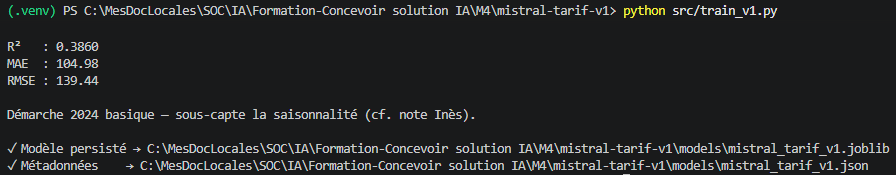

## 2. EDA orientée saisonnalité (~1h30)

Au moins **4 visualisations Seaborn** : boxplot par saison, courbe par
heure-moyenne, scatter température vs cnt, corrélations.

> *« Quelle saisonnalité je vois ? Comment elle explique la
> sous-performance de la baseline ? »*

In [17]:
df = pd.read_csv(DATA_PATH)
df.info()
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      17379 non-null  int64  
 1   date                    17379 non-null  object 
 2   season                  17379 non-null  object 
 3   year                    17379 non-null  int64  
 4   month                   17379 non-null  int64  
 5   hour                    17379 non-null  int64  
 6   is_holiday              17379 non-null  int64  
 7   weekday                 17379 non-null  int64  
 8   is_working_day          17379 non-null  int64  
 9   weather                 17379 non-null  int64  
 10  temperature_norm        17379 non-null  float64
 11  temperature_feels_norm  17379 non-null  float64
 12  humidity_norm           17379 non-null  float64
 13  windspeed_norm          17379 non-null  float64
 14  casual_riders           17379 non-null

,id,date,season,year,month,hour,is_holiday,weekday,is_working_day,weather,temperature_norm,temperature_feels_norm,humidity_norm,windspeed_norm,casual_riders,registered_riders,total_rentals
0,1,2011-01-01,winter,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,winter,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,winter,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


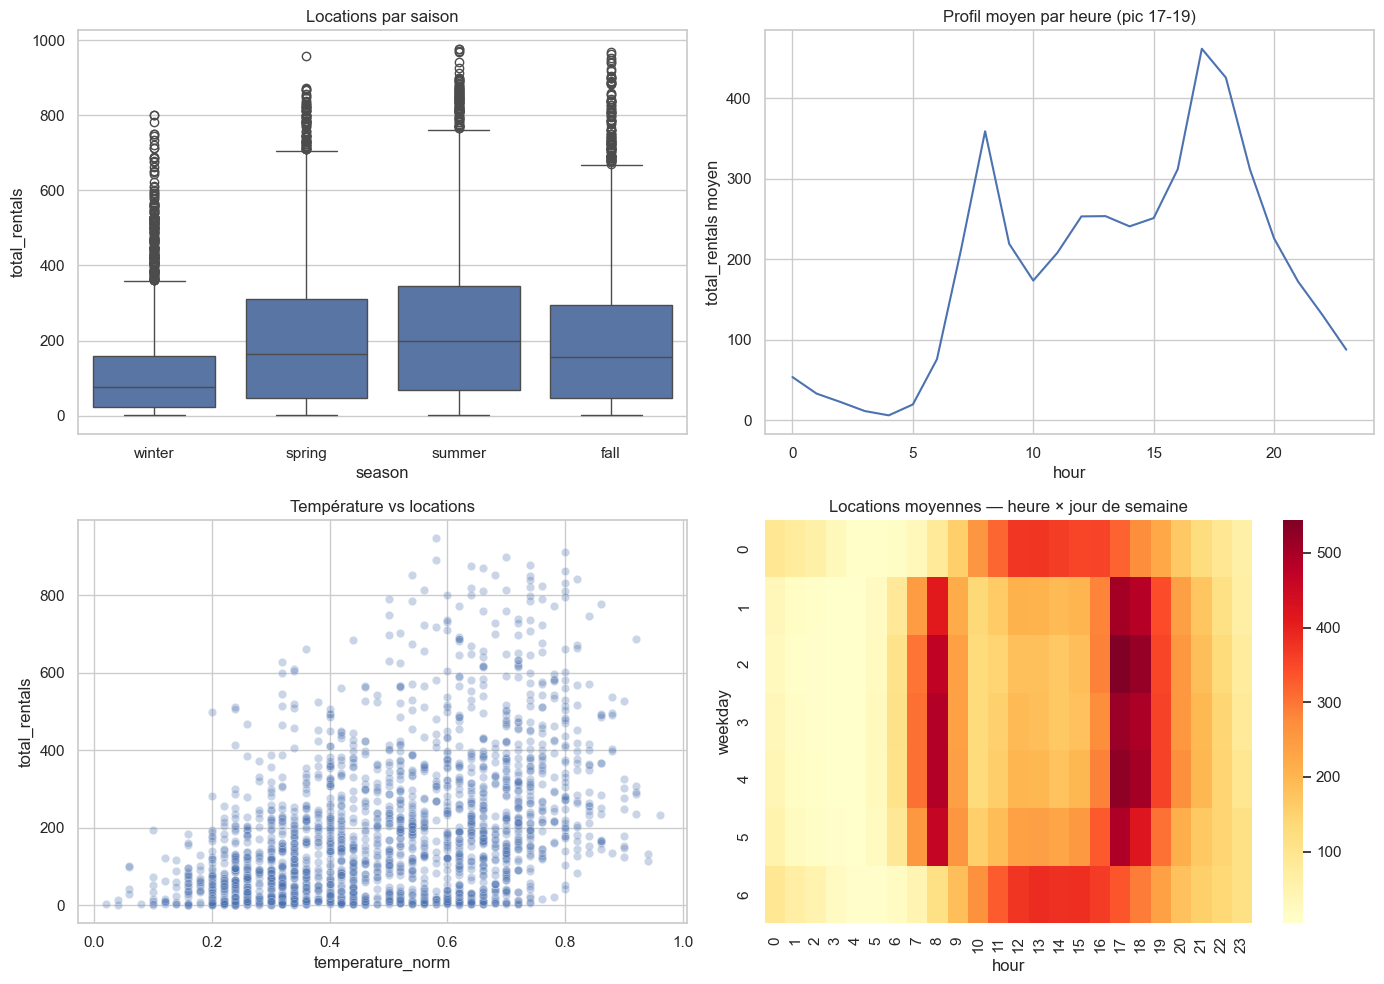

In [18]:
# 4 visualisations EDA
# (boxplot par saison, courbe par heure-moyenne, scatter temp vs cnt, heatmap corrélations)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution cible par saison
sns.boxplot(data=df, x="season", y="total_rentals",
            order=["winter", "spring", "summer", "fall"], ax=axes[0, 0])
axes[0, 0].set_title("Locations par saison")

# 2. Profil moyen par heure
df.groupby("hour")["total_rentals"].mean().plot(ax=axes[0, 1])
axes[0, 1].set_title("Profil moyen par heure (pic 17-19)")
axes[0, 1].set_ylabel("total_rentals moyen")

# 3. Scatter température vs cnt
sns.scatterplot(data=df.sample(2000), x="temperature_norm", y="total_rentals",
                alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_title("Température vs locations")

# 4. Heatmap heure × weekday
pivot = df.pivot_table(values="total_rentals", index="weekday",
                       columns="hour", aggfunc="mean")
sns.heatmap(pivot, cmap="YlOrRd", ax=axes[1, 1])
axes[1, 1].set_title("Locations moyennes — heure × jour de semaine")

plt.tight_layout()
plt.show()

## Analyse des graphiques

1. On remarque sur le graphique `Profil moyen par heure (pic 17-19)`, deux pics :
- le matin vers 8h
- le soir entre 17 et 18h

Surement dû aux personnes qui louent un vélo pour aller ou rentrer du travail


2. Grace au graphique `Locations moyennes — heure × jour de semaine` on remarque que les pic horaires listés au dessus ne sont valable que les jours de la semaine ce qui conforte l'idée de la location pour le trajet du travail.


3. Deux features que cette saisonnalité donne envie de créer (IA) :
- `is_rush_hour` (booléen) :
Les pics identifiés (8h le matin, 17-18h le soir) uniquement en semaine :
```python
df["is_rush_hour"] = (
    (df["hour"].isin([7, 8, 9, 17, 18, 19])) & (df["weekday"] < 5)
).astype(int)
```
Capture directement le comportement "trajet domicile-travail" qui explique les deux pics — information que la baseline linéaire ne pouvait pas modéliser sans ça.

- `hour_sin` / `hour_cos` (encodage cyclique) :
L'heure est cyclique (23h est proche de 0h) — un encodage linéaire briserait cette continuité :
```python
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
```
Permet aux modèles linéaires de mesurer correctement la distance temporelle entre les heures. Complémentaire à is_rush_hour : l'un donne la forme du cycle, l'autre signale les pics.

---

De plus on remarque que plus la température est haute plus la location est forte.

De même on observe un trou de location l'hiver, malgrès certains pic de location certains jour (surement les jours de beau temps).

### Conclusion de l'EDA

- Quelles variables semblent les plus importantes ?<br>
=> moi : Les variables qui sembles les plus importantes sont **`hour`**, `season`, `weekday` et `temperature_norm`

- Pourquoi la baseline linéaire risque-t-elle d'être limitée ?<br>
=> moi : les deux pics seulement en semaine font que les données sont non-linéaires.<br>
=> IA : La relation entre `hour` et `total_rentals` est **non-linéaire** (deux pics distincts, pas une droite). De plus, l'effet de `weekday` **interagit** avec `hour` (les pics n'existent qu'en semaine) : une régression linéaire ne capte pas ces interactions sans features manuelles explicites. Enfin, la distribution de la cible est asymétrique (longue queue à droite), ce que les moindres carrés gèrent mal.

- Quelle famille de modèles t'attends-tu à voir gagner ?<br>
=> moi : HistGradientBoosting d'après le tableau de `cheatsheet_algos_ML_FR.pdf`.<br>
=> IA : **Gradient Boosting** (`HistGradientBoostingRegressor`). Les données présentent des non-linéarités fortes (`hour`, `season`) et des interactions (`hour × weekday`) que les arbres boostés capturent nativement, sans feature engineering supplémentaire. RandomForest sera compétitif mais plus lent.


## 3. Split argumenté + validation croisée (~30 min)

Choisir **`TimeSeriesSplit`** ou **`KFold` stratifié** — justifier.

Mini-cours 02 (split temporel vs stratifié) à consulter.

> 🎓 **Réflexe anti-fuite (la leçon de M2-B1, enfin mise en œuvre).** En M2-B1 tu
> as construit un `Pipeline` sans modèle ni split : la fuite ne pouvait pas se
> produire. Ici tu as **un split ET un modèle** → la règle s'applique : un
> préprocesseur **qui apprend des paramètres** (`StandardScaler`, `SimpleImputer`)
> ne se `fit` **jamais** sur l'ensemble des données. On l'enferme dans le
> `Pipeline` du modèle, et c'est **ce Pipeline** qu'on passe à la validation
> croisée — scikit-learn re-`fit` alors le scaler sur les seuls folds
> d'entraînement. Sinon : fuite → R² **optimiste mensonger**. On le démontre
> juste en dessous.

In [19]:
# préparation des features pour le modèle
# id enlevé car séquentielle et ne donne pas d'information intéressante pour le modèle
FEATURES_NUMERICS: list[str] = [
    'year',
    'month',
    'hour',
    'is_holiday',
    'weekday',
    'is_working_day',
    'weather',
    'temperature_norm',
    'temperature_feels_norm',
    'humidity_norm',
    'windspeed_norm',
    'is_rush_hour'
]
FEATURES_CATEGORICAL: list[str] = [
    'season',  # saison encodée en ordinal (1-4)
]
FEATURES: list[str] = FEATURES_NUMERICS + FEATURES_CATEGORICAL
TARGET: str = "total_rentals"

In [20]:
# Préparation des colonnes manquante ou a tranformer (preprocess manuel)
# 1. Encodage manuel des saisons
df["season"] = df["season"].map({"winter": 1, "spring": 2, "summer": 3, "fall": 4})
# 2. Features d'interaction (heure × jour de semaine)
df["is_rush_hour"] = (
    (df["hour"].isin([7, 8, 9, 17, 18, 19])) & (df["weekday"] < 5)
).astype(int)

X = df[FEATURES].copy()
y = df[TARGET]

print(f"Features utilisées : {list(X.columns)}\n")
print(f"VS colonnes présentes dans le DataFrame : {list(df.columns)}\n")
# Différence des deux pour afficher les colonnes manquantes
missing_columns = set(df.columns) - set(X.columns)
print(f"Colonnes manquantes : {list(missing_columns)}\n")

# On vérifie que le prétraitement n'a pas cassé des colonnes (ex : NaN, inf, -inf)
if X.isnull().any().any():
    print("Attention : certaines colonnes contiennent des valeurs manquantes (NaN) !")
if (X == float("inf")).any().any() or (X == float("-inf")).any().any():
    print("Attention : certaines colonnes contiennent des valeurs infinies (inf ou -inf) !")

df.info()
df.head(10)

Features utilisées : ['year', 'month', 'hour', 'is_holiday', 'weekday', 'is_working_day', 'weather', 'temperature_norm', 'temperature_feels_norm', 'humidity_norm', 'windspeed_norm', 'is_rush_hour', 'season']

VS colonnes présentes dans le DataFrame : ['id', 'date', 'season', 'year', 'month', 'hour', 'is_holiday', 'weekday', 'is_working_day', 'weather', 'temperature_norm', 'temperature_feels_norm', 'humidity_norm', 'windspeed_norm', 'casual_riders', 'registered_riders', 'total_rentals', 'is_rush_hour']

Colonnes manquantes : ['registered_riders', 'total_rentals', 'date', 'id', 'casual_riders']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      17379 non-null  int64  
 1   date                    17379 non-null  object 
 2   season                  17379 non-null  int64  
 3   year                

,id,date,season,year,month,hour,is_holiday,weekday,is_working_day,weather,temperature_norm,temperature_feels_norm,humidity_norm,windspeed_norm,casual_riders,registered_riders,total_rentals,is_rush_hour
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16,0
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40,0
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32,0
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13,0
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1,0
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1,0
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2,0
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3,0
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8,0
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14,0


In [21]:
# TODO — Choisir et importer le splitter adapté (TimeSeriesSplit ou KFold)
# => on choisit TimeSeriesSplit pour les séries temporelles
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = Ridge(alpha=1.0)
splitter = TimeSeriesSplit(n_splits=5)

#### Pourquoi on choisit **TimeSeriesSplit** pour bike_sharing ?

Avec un split aléatoire ou un KFold mélangé, on met dans train et test des observations de périodes proches (mêmes dynamiques saisonnières), ce qui rend les scores plus optimistes. On évalue alors une situation moins proche de la réalité métier.

`bike_sharing` est une série chronologique (heure, jour, mois, saison). Le choix de **TimeSeriesSplit** permet :
- de respecter l'ordre temporel (pas d'information du futur dans l'entraînement) ;
- d'obtenir une mesure de performance plus fiable pour le déploiement ;
- de comparer les modèles dans un cadre anti-fuite cohérent avec le problème.

#### Quel modèle est a priori le meilleur pour ce jeu de données ?

Pour **bike_sharing**, le meilleur candidat a priori est un **modèle de Gradient Boosting** (notamment `HistGradientBoostingRegressor`) :
- il capte bien les **relations non linéaires** (`hour`, `season`, `temperature_norm`) ;
- il gère naturellement les **interactions** (ex. `hour × weekday`) ;
- il est souvent plus performant qu'un modèle linéaire sans gros feature engineering.

En pratique, on s'attend à ce que :
- **Ridge / linéaire** soit une baseline solide mais limitée sur les pics ;
- **RandomForest** améliore la non-linéarité mais parfois moins régulier ;
- **HistGradientBoosting** offre le meilleur compromis performance/robustesse sur ce type de données tabulaires saisonnières.

Conclusion : la décision finale doit se faire sur le **même splitter temporel** pour tous les modèles, avec priorité à la stabilité des métriques (MAE/RMSE/R²) sur plusieurs folds.

### 🔬 Fuite de données — démonstration (à faire une fois)

Avant de lancer la cellule : vérifie que ton `X` **exclut**
`casual_riders` / `registered_riders` (ils somment la cible → fuite de cible,
R² ~1.0). La cellule compare ensuite le R² en CV selon que le `StandardScaler`
est fitté sur **tout** `X` (fuite de prétraitement) ou **dans le `Pipeline`**.

> **À rédiger après exécution** (1-2 phrases, → journal de bord) : quel écart
> observes-tu ? Sur 17k lignes il sera **faible** — explique *dans quel cas* il
> exploserait (peu de données, imputation moyenne/médiane, encodage supervisé).
> C'est pour ça qu'on encapsule le prétraitement **par défaut**, pas seulement
> quand la fuite se voit.

In [22]:
# 🔬 Démonstration fuite vs propre (Ridge) — à exécuter une fois le
# preprocessing complété (FEATURES rempli dans preprocess.py).
# Cellule pré-écrite : tu n'as pas à la coder, juste à la faire tourner.
import importlib
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

# Recharge le module pour éviter d'utiliser une ancienne version en cache.
try:
    import src.preprocess as preprocess
except ModuleNotFoundError:
    import preprocess

preprocess = importlib.reload(preprocess)
load_dataset = preprocess.load_dataset

try:
    X_demo, y_demo = load_dataset(DATA_PATH)   # SANS casual_riders / registered_riders (fuite de cible)
    splitter_demo = TimeSeriesSplit(n_splits=5)

    # (1) FUITE : le scaler est fitté sur TOUT X, avant la validation croisée
    X_leak = StandardScaler().fit_transform(X_demo)
    r2_leak = cross_val_score(Ridge(alpha=1.0), X_leak, y_demo, cv=splitter_demo, scoring="r2").mean()

    # (2) PROPRE : le scaler vit DANS le pipeline -> re-fitté sur chaque fold d'entraînement
    r2_clean = cross_val_score(
        make_pipeline(StandardScaler(), Ridge(alpha=1.0)), X_demo, y_demo, cv=splitter_demo, scoring="r2"
    ).mean()

    display(pd.DataFrame(
        {"R² moyen (CV)": [round(r2_leak, 4), round(r2_clean, 4)]},
        index=["fuite (fit sur tout X)", "propre (fit dans le pipeline)"],
    ))
except Exception as e:
    print(f"⏳ Démo à relancer une fois load_dataset() opérationnel (FEATURES rempli). Détail : {e}")


,R² moyen (CV)
fuite (fit sur tout X),0.3917
propre (fit dans le pipeline),0.3917


Ici on ne voit pas les fuites car on a déjà enlevé les 2 colonnes qui donnent l'information du résultat... Donc pas de R² à 1!

## 4. Benchmark — 3 familles minimum (~2h)

**Famille A** — Linéaire (Ridge ou variante)  
**Famille B** — Arbre / RandomForest  
**Famille C** — Gradient Boosting (HistGradientBoostingRegressor)

Pour chaque modèle :
- Mêmes folds, mêmes métriques
- MAE, RMSE, R²
- Temps train, latence inférence
- Persistance `.joblib` dans `models/`

> ⚠️ **Règle d'or** : réutilise **exactement le même splitter** que la section 3 (Split). Un splitter différent d'un modèle à l'autre = comparaison invalide.


In [23]:
# Benchmark de 3 familles de modèles avec le même splitter temporel.
# Objectif : comparer performance (MAE/RMSE/R2), coût d'entraînement et latence d'inférence.

from hashlib import sha256
import json
from datetime import datetime
from time import perf_counter
from importlib.metadata import version
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# Même splitter pour tous les modèles => comparaison équitable.
# splitter = TimeSeriesSplit(n_splits=5) # défini plus haut dans le notebook

# Dictionnaire de factories : chaque valeur reconstruit un modèle "neuf" à chaque itération.
model_factories = {
    "Ridge (lineaire + scaling)": lambda: make_pipeline(
        StandardScaler(), Ridge(alpha=1.0)
    ),
    "RandomForestRegressor": lambda: RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "HistGradientBoostingRegressor": lambda: HistGradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
}

rows = []

# Boucle principale : on évalue chaque famille dans les mêmes conditions.
for model_name, factory in model_factories.items():
    # Instancie le modèle à tester.
    model = factory()

    # Validation croisée temporelle : métriques robustes sur plusieurs folds.
    cv = cross_validate(
        model,
        X,
        y,
        cv=splitter,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
        return_train_score=False,
    )

    # Entraînement final sur tout X,y pour estimer le temps de fit en conditions "prod".
    t0 = perf_counter()
    model.fit(X, y)
    train_time_s = perf_counter() - t0

    # Mesure de latence moyenne par ligne sur un échantillon d'inférence.
    X_infer = X.tail(1000) if len(X) >= 1000 else X
    t1 = perf_counter()
    _ = model.predict(X_infer)
    infer_latency_ms = (perf_counter() - t1) * 1000 / len(X_infer)

    # Stocke les résultats agrégés pour ce modèle.
    rows.append(
        {
            "Modele": model_name,
            "MAE (CV mean)": -cv["test_mae"].mean(),
            "RMSE (CV mean)": -cv["test_rmse"].mean(),
            "R2 (CV mean)": cv["test_r2"].mean(),
            "Std R2 (CV)": cv["test_r2"].std(),
            "Temps train (s)": train_time_s,
            "Latence (ms/ligne)": infer_latency_ms,
        }
    )

    # sauvegarde du modèle entraîné pour usage futur (ex : déploiement)
    model_path = Path(f"../models/{model_name.replace(' ', '_')}.joblib")
    model_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, model_path, compress=3)
    # et écrit un fichier JSON meta contenant: versions, horodatage, sha256 du dataset, hyperparamètres, métriques internes, colonnes de features et mapping de la cible.
    meta_path = model_path.with_suffix(".json")
    # si modèle HistGradientBoostingRegressor ajout information que c'est le modèle retenu dans le json
    if isinstance(model, HistGradientBoostingRegressor):
        meta = {
            "selected_model": True}
    else:
        meta = {"selected_model": False}
    meta.update({
        "versions": {
            "python": sys.version,
            "scikit-learn": version("scikit-learn"),
            "pandas": pd.__version__,
            "numpy": np.__version__,
        },
        "timestamp": datetime.now().isoformat(),
        "dataset_sha256": sha256(pd.util.hash_pandas_object(X, index=True).values).hexdigest(),
        "hyperparameters": {k: str(v) for k, v in model.get_params(deep=True).items()},
        "metrics": {
            "MAE (CV mean)": -cv["test_mae"].mean(),
            "RMSE (CV mean)": -cv["test_rmse"].mean(),
            "R2 (CV mean)": cv["test_r2"].mean(),
            "Std R2 (CV)": cv["test_r2"].std(),
        },
        "feature_columns": X.columns.tolist(),
        "target_mapping": y.unique().tolist() if y.dtype == "object" else None,
    })
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=4, ensure_ascii=False)

# Construit le tableau final trié par qualité prédictive (R2 décroissant).
benchmark_df = (
    pd.DataFrame(rows)
    .sort_values(by="R2 (CV mean)", ascending=False)
    .reset_index(drop=True)
)

# Affichage formaté pour lecture métier.
display(
    benchmark_df.style.format(
        {
            "MAE (CV mean)": "{:.2f}",
            "RMSE (CV mean)": "{:.2f}",
            "R2 (CV mean)": "{:.3f}",
            "Std R2 (CV)": "{:.3f}",
            "Temps train (s)": "{:.3f}",
            "Latence (ms/ligne)": "{:.4f}",
        }
    )
)

,Modele,MAE (CV mean),RMSE (CV mean),R2 (CV mean),Std R2 (CV),Temps train (s),Latence (ms/ligne)
0,HistGradientBoostingRegressor,51.89,76.17,0.796,0.124,0.767,0.0090
1,RandomForestRegressor,53.78,81.03,0.772,0.129,4.739,0.1235
2,Ridge (lineaire + scaling),105.39,138.58,0.392,0.067,0.009,0.0009


## Explications validation croisée

### Analyse des résultats (MAE, RMSE, R²)
...
Les troiiques rac du tableauontent des choses complémentaires :
- **MAE** = erreur moyenne en nombre de locations (facile à expliquer métier).
- **RMSE** = pénalise davantage les grosses erreurs (important quand on sous/sur-estime fortement les pics).
- **R²** = part de la variance expliquée (plus proche de 1, mieux c'est).
- **Std R² (CV)** = écart-type du R² entre les folds de validation croisée. Plus il est faible, plus le modèle est stable.
- **Temps train (s)** = durée d'entraînement du modèle sur l'ensemble d'entraînement. Permet d'évaluer le coût de recalibrage.
- **Latence (ms/ligne)** = temps moyen de prédiction par observation. Utile pour vérifier la compatibilité avec les contraintes de temps de réponse.

## 5. Tableau comparatif (~30 min, mercredi)

Remplis `benchmark_table.md` avec les chiffres + interprétation pour
Inès Tabet (lisible actuaire, pas data scientist).

## Explicabilité des modèles

### **1\. Ridge (Régression linéaire + Scaling)**

✅ **Explicabilité maximale**

- **Pourquoi ?**
    - Modèle **linéaire** : la prédiction est une somme pondérée des features. `Prédiction = w₁·x₁ + w₂·x₂ + ... + wₙ·xₙ + b`
    - **Interprétation directe** :
        - Le coefficient `wᵢ` indique **l'impact exact** de la feature `xᵢ` sur la prédiction (en gardant les autres features constantes).
        - Exemple : Si `w₁ = 0.5`, une augmentation de 1 unité de `x₁` augmente la prédiction de 0.5 (toutes choses égales par ailleurs).
    - **Scaling** (standardisation) ne change pas l'interprétation des coefficients, mais facilite l'optimisation.
- **Limites** :
    - Suppose une **relation linéaire** entre les features et la cible (peut être irréaliste).
    - Sensible aux **outliers** (mais moins que la régression standard).

👉 **Idéal pour** : Comprendre les relations directes entre features et cible, ou lorsque la transparence est critique (ex : santé, finance).

---

### 🔹 **2\. RandomForestRegressor**

⚠️ **Explicabilité moyenne**

- **Pourquoi ?**
    - Basé sur **des arbres de décision** (chaque arbre est explicable individuellement).
    - **Outils d'interprétation disponibles** :
        - **Feature Importance** : Indique quelles features contribuent le plus aux prédictions (basé sur la réduction de l'erreur).
        - **Partial Dependence Plots (PDP)** : Montre l'effet moyen d'une feature sur la prédiction.
        - **SHAP/LIME** : Méthodes avancées pour expliquer des prédictions individuelles.
    - **Mais** :
        - Le modèle final est une **combinaison de centaines d'arbres** → pas de formule simple comme Ridge.
        - Les interactions entre features sont complexes à interpréter.
- **Limites** :
    - Moins stable que Ridge (petites variations dans les données peuvent changer les feature importance).
    - Sensible au **surapprentissage** si les arbres sont trop profonds.

👉 **Idéal pour** : Quand Ridge est trop restrictif (relations non-linéaires), mais où on veut une explication globale (pas forcément individuelle).

---

### 🔹 **3\. HistGradientBoostingRegressor**

❌ **Explicabilité faible**

- **Pourquoi ?**
    - Version **optimisée du Gradient Boosting** (comme XGBoost/LightGBM).
    - **Principe** : Les arbres sont construits **séquentiellement** pour corriger les erreurs des arbres précédents.
    - **Problèmes d'explicabilité** :
        - Pas de formule linéaire ou d'arbres simples à lire.
        - Les **feature importance** existent, mais sont **moins stables** et moins intuitives que pour RandomForest.
        - Les interactions entre features sont **très complexes** (le modèle "apprend" des patterns imbriqués).
    - **Outils d'interprétation** :
        - **SHAP** ou **LIME** sont **indispensables** pour expliquer des prédictions individuelles.
        - Les **Partial Dependence Plots** aident, mais sont moins précis qu'avec RandomForest.
- **Limites** :
    - **Boîte noire** : Difficile de comprendre "pourquoi" le modèle a fait une prédiction sans outils externes.
    - Sensible au **tuning des hyperparamètres** (learning rate, profondeur des arbres, etc.).

👉 **Idéal pour** : Quand la performance pure est prioritaire (ex : compétitions Kaggle), mais **pas** pour des applications où l'explicabilité est critique.

---

## 📊 **Tableau comparatif rapide**

Copier le tableau

| Modèle | Explicabilité | Interprétation directe | Outils d'aide | Performance typique |
| --- | --- | --- | --- | --- |
| **Ridge** | ⭐⭐⭐⭐⭐ | Coefficients linéaires | Aucune | Moyenne |
| **RandomForest** | ⭐⭐⭐ | Feature importance | SHAP/LIME/PDP | Élevée |
| **HistGradientBoosting** | ⭐ | Feature importance (peu fiable) | SHAP/LIME obligatoire | Très élevée |

## 6. Verdict + decision card (~30 min, mercredi)

- `verdict.md` : 5 lignes max, recommandation chiffrée
- `decision_card.md` : ta version perso de la grille de décision C4
  (à confronter à la collective)

## 7. Restitution + grille collective (mercredi 11h30-12h45)

**Geste pédagogique central** — co-construction de la grille de
décision C4 sur Excalidraw partagé.

Archivée ensuite dans `ressources-publiques/grille_decision_C4.md`.

## 8. Robustesse

En **pré-requis** effectuer la commande suivant pour sauvegarder le modèle choisi :
`cp models/HistGradientBoostingRegressor.joblib models/mistral_tarif_v2.joblib`

In [44]:
# scikit-learn — sur le modèle retenu du benchmark
import joblib

model = joblib.load("../models/mistral_tarif_v2.joblib")   # ton meilleur modèle
x_rob = X.iloc[[0]].copy()
base = model.predict(x_rob)[0]
print(f"Prédiction normale : {base:.0f}")

# 1) Entrée HORS-DISTRIBUTION : une valeur normalisée aberrante (jamais vue)
x_ood = x_rob.copy()
x_ood["temperature_norm"] = 5.2          # censé être ~0-1
print(f"Prédiction OOD     : {model.predict(x_ood)[0]:.0f}  ← extrapolation ?")
x_ood["temperature_norm"] = 0.2          # censé être ~0-1
x_ood["humidity_norm"] = 3             # censé être ~0-1
print(f"Prédiction OOD     : {model.predict(x_ood)[0]:.0f}  ← extrapolation ?")
x_ood["humidity_norm"] = 0.5             # censé être ~0-1
x_ood["windspeed_norm"] = 5             # censé être ~0-1
print(f"Prédiction OOD     : {model.predict(x_ood)[0]:.0f}  ← extrapolation ?")
x_ood["windspeed_norm"] = 0.5             # censé être ~0-1
x_ood["hour"] = 38          # censé être ~0-24
print(f"Prédiction OOD     : {model.predict(x_ood)[0]:.0f}  ← extrapolation ?")

# 2) SENSIBILITÉ : une petite perturbation change-t-elle beaucoup la sortie ?
x_pert = x_rob.copy()
x_pert["humidity_norm"] *= 1.05          # +5 %
delta = model.predict(x_pert)[0] - base
print(f"Écart sous +5% humidité : {delta:+.0f}")

Prédiction normale : 39
Prédiction OOD     : 44  ← extrapolation ?
Prédiction OOD     : 37  ← extrapolation ?
Prédiction OOD     : 30  ← extrapolation ?
Prédiction OOD     : 31  ← extrapolation ?
Écart sous +5% humidité : -2


Le test OOD (température/humidité/vent/heure hors plage) vérifie que le modèle ne “plante” pas, mais peut produire des prédictions peu fiables en extrapolation.

Le test de sensibilité (+5% humidité) mesure la stabilité locale : si l’écart est faible, le modèle est stable ; s’il est fort, il est sensible à de petites variations.

Donc, le modèle est robuste en interpolation (données proches du train), mais sa robustesse hors distribution reste limitée.